# Augmented Dataset Analysis

This notebook compares the original training dataset with the copy-paste augmented dataset, visualizes what changed in one example, and summarizes the dataset spec including small, medium, and large object counts.

It is designed to work directly with the experiment output from `experiments/05_copy_paste_exp.py`.


In [5]:
def draw_boxes(ax, image_path: Path, boxes: list[tuple[int, float, float, float, float]], color: str, title: str) -> None:
    with Image.open(image_path) as img:
        image = np.array(img.convert("RGB"))
    ax.imshow(image)
    height, width = image.shape[:2]
    for box in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy(box, width, height)
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
    ax.set_title(title)
    ax.axis("off")

## Dataset Spec and Size Breakdown

This section summarizes the augmented dataset and counts objects using COCO-style size buckets:
- small: area < 32^2 pixels
- medium: 32^2 to 96^2 pixels
- large: area > 96^2 pixels

Original dataset root: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo
Augmented dataset root: /home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_4_Copy_Paste_Augmentation/augmented_dataset



,size_bucket,count
0,small,26421
1,medium,9462
2,large,0


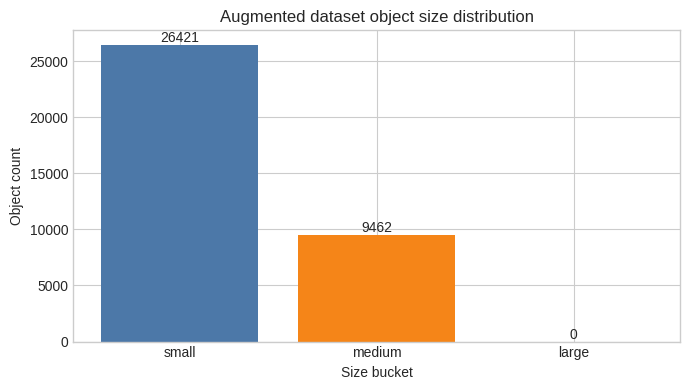

In [6]:
augmented_rows = collect_dataset_rows(AUGMENTED_DATASET_ROOT)
original_rows = collect_dataset_rows(ORIGINAL_DATASET_ROOT)

print(f"Original dataset root: {ORIGINAL_DATASET_ROOT}")
print(f"Augmented dataset root: {AUGMENTED_DATASET_ROOT}")
print()

summary_rows = []
for name, df, root in [
    ("original", original_rows, ORIGINAL_DATASET_ROOT),
    ("augmented", augmented_rows, AUGMENTED_DATASET_ROOT),
]:
    image_count = 0
    split_dirs = find_split_dirs(root)
    for split_dir in split_dirs.values():
        image_count += sum(1 for p in (split_dir / "images").rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
    summary_rows.append(
        {
            "dataset": name,
            "images": image_count,
            "objects": int(len(df)),
            "avg_objects_per_image": round(len(df) / image_count, 3) if image_count else 0.0,
            "small": int((df["size_bucket"] == "small").sum()) if not df.empty else 0,
            "medium": int((df["size_bucket"] == "medium").sum()) if not df.empty else 0,
            "large": int((df["size_bucket"] == "large").sum()) if not df.empty else 0,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

if not augmented_rows.empty:
    size_counts = (
        augmented_rows["size_bucket"].value_counts()
        .reindex(["small", "medium", "large"], fill_value=0)
        .rename_axis("size_bucket")
        .reset_index(name="count")
    )
    display(size_counts)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(size_counts["size_bucket"], size_counts["count"], color=["#4c78a8", "#f58518", "#54a24b"])
    ax.set_title("Augmented dataset object size distribution")
    ax.set_xlabel("Size bucket")
    ax.set_ylabel("Object count")
    for idx, value in enumerate(size_counts["count"]):
        ax.text(idx, value, str(value), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()
else:
    print("No augmented objects found.")

## Visual Comparison: Original vs Augmented

This section picks one augmented image, finds its source image, and highlights which boxes were newly added by augmentation.

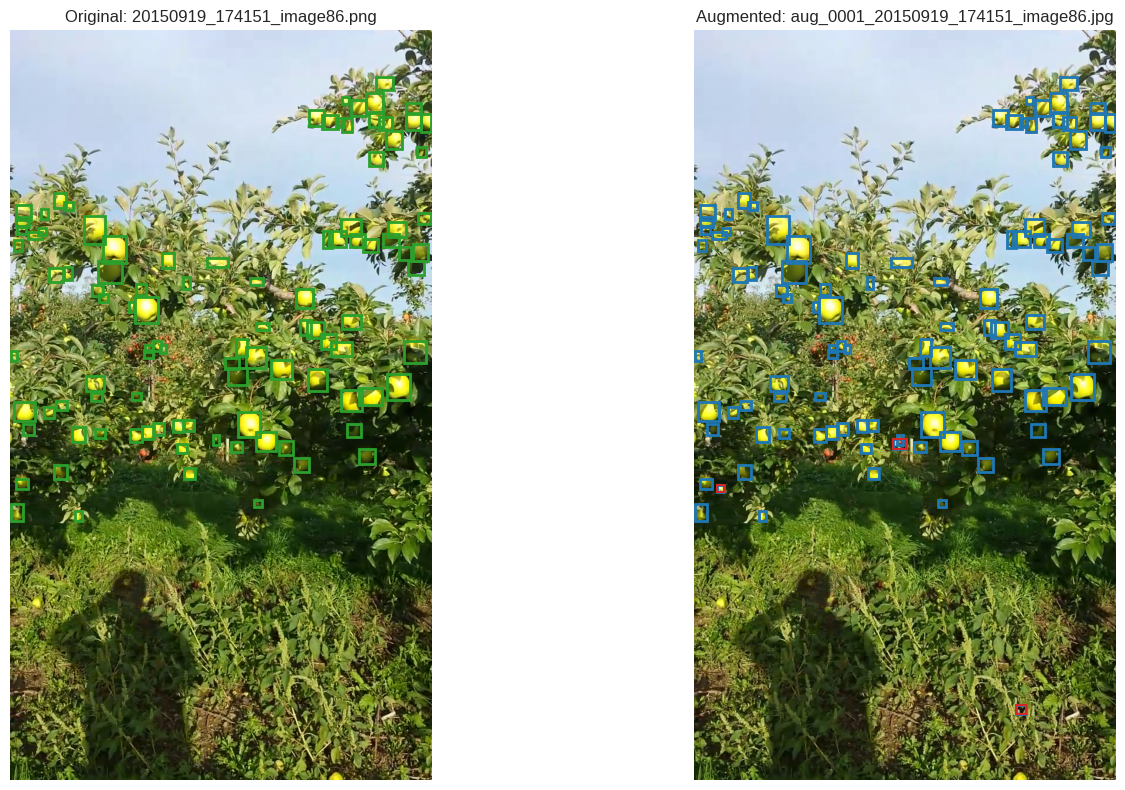

Sample augmented image: aug_0001_20150919_174151_image86.jpg
Source image: 20150919_174151_image86.png
Original boxes: 101
Augmented boxes: 104
Added boxes from augmentation: 3


In [8]:
augmented_image_dir = AUGMENTED_DATASET_ROOT / "train" / "images"
augmented_label_dir = AUGMENTED_DATASET_ROOT / "train" / "labels"
original_image_dir = ORIGINAL_DATASET_ROOT / "train" / "images"
original_label_dir = ORIGINAL_DATASET_ROOT / "train" / "labels"

augmented_images = sorted(
    [p for p in augmented_image_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS and p.name.startswith("aug_")]
)

if not augmented_images:
    print("No augmented images found in the augmented dataset.")
else:
    sample_aug_image = augmented_images[0]
    sample_aug_label = augmented_label_dir / f"{sample_aug_image.stem}.txt"
    source_stem = split_augmented_source_name(sample_aug_image)

    source_image_candidates = list(original_image_dir.rglob(f"{source_stem}.*"))
    if source_image_candidates:
        sample_original_image = source_image_candidates[0]
    else:
        sample_original_image = None

    sample_aug_boxes = load_yolo_boxes(sample_aug_label)
    sample_original_boxes = []
    if sample_original_image is not None:
        sample_original_boxes = load_yolo_boxes(original_label_dir / f"{sample_original_image.stem}.txt")

    added_boxes = []
    matched_original_indices = set()
    if sample_original_image is not None and sample_original_boxes:
        with Image.open(sample_aug_image) as img:
            aug_w, aug_h = img.size
        for aug_box in sample_aug_boxes:
            best_iou = 0.0
            best_idx = None
            for idx, orig_box in enumerate(sample_original_boxes):
                if idx in matched_original_indices:
                    continue
                if int(orig_box[0]) != int(aug_box[0]):
                    continue
                score = iou_xyxy(orig_box, aug_box, aug_w, aug_h)
                if score > best_iou:
                    best_iou = score
                    best_idx = idx
            if best_iou >= 0.9 and best_idx is not None:
                matched_original_indices.add(best_idx)
            else:
                added_boxes.append(aug_box)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    if sample_original_image is not None:
        draw_boxes(axes[0], sample_original_image, sample_original_boxes, color="#2ca02c", title=f"Original: {sample_original_image.name}")
    else:
        axes[0].text(0.5, 0.5, f"Could not find source image for {sample_aug_image.name}", ha="center", va="center")
        axes[0].axis("off")

    draw_boxes(axes[1], sample_aug_image, sample_aug_boxes, color="#1f77b4", title=f"Augmented: {sample_aug_image.name}")
    for box in added_boxes:
        with Image.open(sample_aug_image) as img:
            aug_w, aug_h = img.size
        x1, y1, x2, y2 = yolo_to_xyxy(box, aug_w, aug_h)
        axes[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#d62728", linewidth=1.5))
    plt.tight_layout()
    plt.show()

    print(f"Sample augmented image: {sample_aug_image.name}")
    print(f"Source image: {sample_original_image.name if sample_original_image else 'not found'}")
    print(f"Original boxes: {len(sample_original_boxes)}")
    print(f"Augmented boxes: {len(sample_aug_boxes)}")
    print(f"Added boxes from augmentation: {len(added_boxes)}")